#  Artificial Intelligence and Machine Learning. Implementation of Convolutional Neural Network using Keras.

In [ ]:
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
train_dir = "/content/drive/MyDrive/AI and ML/Week 5/train"
test_dir = "/content/drive/MyDrive/AI and ML/Week 5/test"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Task 1: Data Understanding and Visualization

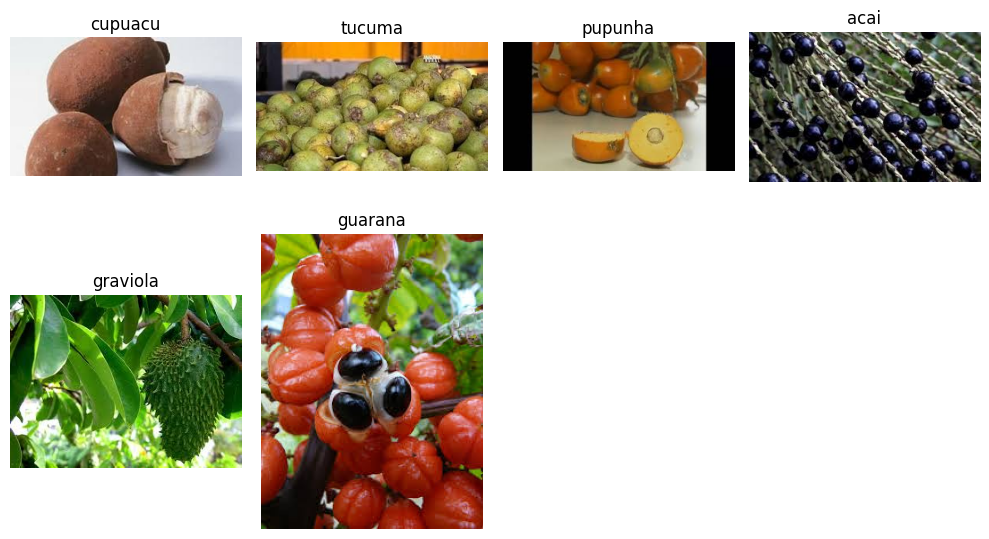

In [ ]:
class_names = os.listdir(train_dir)

images = []
labels = []

# Pick one random image from each class
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)

        img = Image.open(img_path)
        images.append(img)
        labels.append(class_name)

# Plot images (2 rows grid)
plt.figure(figsize=(10, 6))

for i in range(len(images)):
    plt.subplot(2, len(images)//2 + 1, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Check for corrupted images
corrupted_images = []

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            try:
                img = Image.open(img_path)
                img.verify()  # check corruption
            except (IOError, SyntaxError):
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image: {img_path}")

if len(corrupted_images) == 0:
    print("No corrupted images found.")

No corrupted images found.


# Task 2: Loading and Preprocessing Image Data

In [ ]:
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=True,
  validation_split=validation_split,
  subset='training',
  seed=123
)
num_classes = len(train_ds.class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.


In [ ]:
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  train_dir,
  labels='inferred',
  label_mode='int',
  image_size=(img_height, img_width),
  interpolation='nearest',
  batch_size=batch_size,
  shuffle=False,
  validation_split=validation_split,
  subset='validation',
  seed=123
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Task 3: Implementing CNN

In [ ]:
model = keras.Sequential([

    # Conv Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),

    # Conv Layer 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected Layers
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),

    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Task 4: Compiling and Training the Model

> Add blockquote



In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    batch_size=16,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.1655 - loss: 1.8922
Epoch 1: val_loss improved from None to 2.06139, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5



Epoch 1: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 643ms/step - accuracy: 0.1528 - loss: 1.9377 - val_accuracy: 0.1111 - val_loss: 2.0614
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step - accuracy: 0.3310 - loss: 1.7642
Epoch 2: val_loss improved from 2.06139 to 1.76947, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5



Epoch 2: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 527ms/step - accuracy: 0.3056 - loss: 1.7775 - val_accuracy: 0.1111 - val_loss: 1.7695
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.4757 - loss: 1.6690
Epoch 3: val_loss improved from 1.76947 to 1.74872, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5



Epoch 3: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 857ms/step - accuracy: 0.4583 - loss: 1.6466 - val_accuracy: 0.1111 - val_loss: 1.7487
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.2633 - loss: 1.5691
Epoch 4: val_loss improved from 1.74872 to 1.24387, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5



Epoch 4: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.3056 - loss: 1.5159 - val_accuracy: 0.8889 - val_loss: 1.2439
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 727ms/step - accuracy: 0.5943 - loss: 1.2664
Epoch 5: val_loss did not improve from 1.24387
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 911ms/step - accuracy: 0.6111 - loss: 1.2533 - val_accuracy: 0.4444 - val_loss: 1.2841
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.5804 - loss: 1.0742
Epoch 6: val_loss improved from 1.24387 to 1.23637, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5


...


Epoch 7: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 536ms/step - accuracy: 0.7222 - loss: 0.8499 - val_accuracy: 0.9444 - val_loss: 0.5072
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.8009 - loss: 0.6310
Epoch 8: val_loss did not improve from 0.50724
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 758ms/step - accuracy: 0.7778 - loss: 0.6314 - val_accuracy: 0.7222 - val_loss: 1.2237
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.9560 - loss: 0.4092
Epoch 9: val_loss improved from 0.50724 to 0.48418, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5



Epoch 9: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 776ms/step - accuracy: 0.9306 - loss: 0.4291 - val_accuracy: 0.8889 - val_loss: 0.4842
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step - accuracy: 0.9705 - loss: 0.3167
Epoch 10: val_loss did not improve from 0.48418
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 472ms/step - accuracy: 0.9583 - loss: 0.3260 - val_accuracy: 0.6667 - val_loss: 0.7155
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.9699 - loss: 0.1864
Epoch 11: val_loss did not improve from 0.48418
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - accuracy: 0.9722 - loss: 0.1709 - val_accuracy: 0.7778 - val_loss: 1.2556
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9902 - loss: 0.1727
Epoch 12: val_loss improved from 0.48418 to 0.46226, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5



Epoch 12: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 875ms/step - accuracy: 0.9861 - loss: 0.1558 - val_accuracy: 0.8333 - val_loss: 0.4623
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 1.0000 - loss: 0.0561
Epoch 13: val_loss improved from 0.46226 to 0.40572, saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5



Epoch 13: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 539ms/step - accuracy: 1.0000 - loss: 0.0622 - val_accuracy: 0.8889 - val_loss: 0.4057
Epoch 14/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 1.0000 - loss: 0.0418
Epoch 14: val_loss did not improve from 0.40572
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 789ms/step - accuracy: 1.0000 - loss: 0.0390 - val_accuracy: 0.7778 - val_loss: 0.5223
Epoch 15/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 1.0000 - loss: 0.0252
Epoch 15: val_loss did not improve from 0.40572
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 530ms/step - accuracy: 1.0000 - loss: 0.0256 - val_accuracy: 0.8333 - val_loss: 0.5634
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 1.0000 - loss: 0.0182
Epoch 16: val_loss did not improve from 0.40572
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 762ms/step - accuracy: 1.0000 - loss: 0.0135 - val_accuracy: 0.8889 - val_loss: 0.4501
Epoch 17/250
3/3 ━━━━━━━


Epoch 17: finished saving model to /content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 535ms/step - accuracy: 1.0000 - loss: 0.0202 - val_accuracy: 0.8333 - val_loss: 0.3415
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 1.0000 - loss: 0.0084
Epoch 18: val_loss did not improve from 0.34148
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 474ms/step - accuracy: 1.0000 - loss: 0.0122 - val_accuracy: 0.6667 - val_loss: 0.9523
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9595 - loss: 0.0702
Epoch 19: val_loss did not improve from 0.34148
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 741ms/step - accuracy: 0.9722 - loss: 0.0504 - val_accuracy: 0.8333 - val_loss: 0.6898
Epoch 20/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 1.0000 - loss: 0.0299
Epoch 20: val_loss did not improve from 0.34148
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 794ms/step - accuracy: 1.0000 - loss: 0.0326 - val_accuracy: 0.8333 - val_loss: 0.7939
Epoch 21/250
3/3 ━━━━━━━

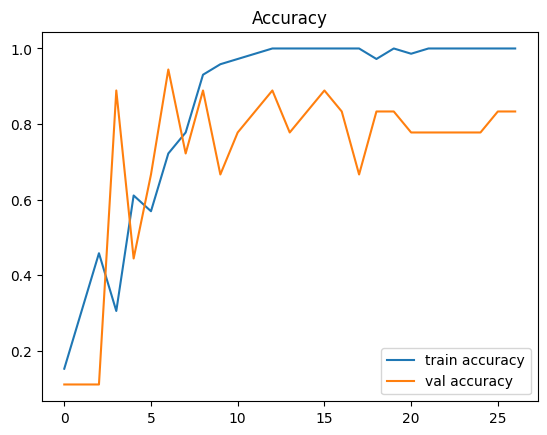

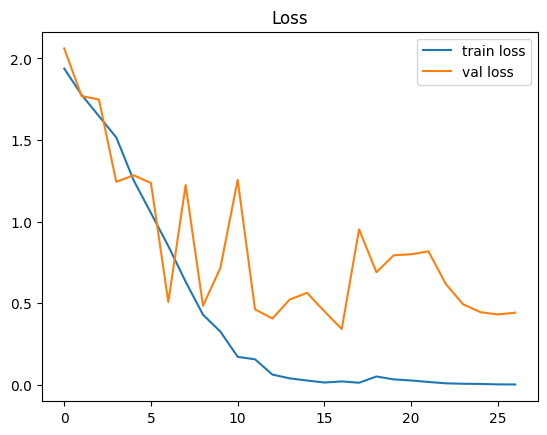

In [ ]:
# Accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.title("Loss")
plt.show()

# Task 5: Evaluating the Model

In [ ]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=32,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))

Found 30 files belonging to 6 classes.


In [ ]:
test_loss, test_acc = model.evaluate(test_ds)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.5000 - loss: 1.2324
Test Loss: 1.2324
Test Accuracy: 0.5000


# Task 6: Saving and Loading the Model

In [ ]:
model.save("/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/cnn_fruit_model.h5")

In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("/content/drive/MyDrive/AI and Machine Learning - 6th Sem/Week 5/cnn_fruit_model.h5")

In [ ]:
loss, acc = loaded_model.evaluate(test_ds)

print(f"Loaded Model Accuracy: {acc:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 631ms/step - accuracy: 0.5000 - loss: 1.2324
Loaded Model Accuracy: 0.5000


# Task 7: Predictions and Classification Report

In [ ]:
y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_pred.extend(preds)
    y_true.extend(labels.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


In [ ]:
from sklearn.metrics import classification_report

labels = np.unique(y_true)

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=[class_names[i] for i in labels]
))

              precision    recall  f1-score   support

     cupuacu       0.56      1.00      0.71         5
      tucuma       0.75      0.60      0.67         5
     pupunha       0.50      0.60      0.55         5
        acai       0.60      0.60      0.60         5
    graviola       0.00      0.00      0.00         5
     guarana       0.20      0.20      0.20         5

    accuracy                           0.50        30
   macro avg       0.43      0.50      0.45        30
weighted avg       0.43      0.50      0.45        30

